In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font family: Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family: Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding top:120px;}
div.text_cell_render ul li {font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font color="red" size="6"> 03_군집화(비지도학습)</font></b>

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(40, 95) # 40부터 95까지의 정수중 하나를 무작위 선택 반환

47

In [6]:
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터
    data.append([random.randint(60, 95), random.randint(160, 195)])
#len(data)

100

In [9]:
# 여자 데이터만
for female in data[:100:2]:
    print(female, end=' ')
# 남자 데이터만
print('\n----------------------------------')
for male in data[1:100:2]:
    print(male, end=' ')

[54, 141] [45, 158] [58, 164] [42, 140] [50, 157] [41, 152] [65, 155] [53, 145] [67, 159] [43, 142] [65, 161] [50, 169] [49, 165] [63, 169] [63, 142] [45, 157] [61, 168] [69, 141] [43, 148] [55, 159] [42, 159] [52, 148] [53, 145] [43, 140] [52, 162] [42, 146] [46, 148] [62, 153] [51, 147] [56, 158] [52, 148] [47, 164] [67, 140] [61, 154] [46, 160] [44, 160] [46, 158] [66, 170] [43, 147] [55, 165] [40, 157] [50, 154] [63, 167] [42, 160] [62, 148] [58, 158] [59, 155] [50, 150] [54, 148] [42, 155] 
----------------------------------
[62, 167] [81, 173] [94, 170] [83, 185] [92, 179] [94, 169] [62, 171] [61, 194] [89, 185] [78, 180] [71, 171] [89, 168] [82, 190] [74, 179] [73, 168] [95, 190] [64, 166] [65, 194] [77, 169] [89, 176] [63, 164] [60, 170] [60, 188] [61, 179] [67, 192] [69, 173] [80, 163] [86, 166] [93, 184] [89, 176] [81, 168] [66, 160] [69, 172] [61, 194] [90, 167] [67, 168] [68, 160] [67, 178] [90, 180] [88, 187] [86, 163] [73, 190] [88, 188] [95, 191] [67, 162] [89, 162] [88,

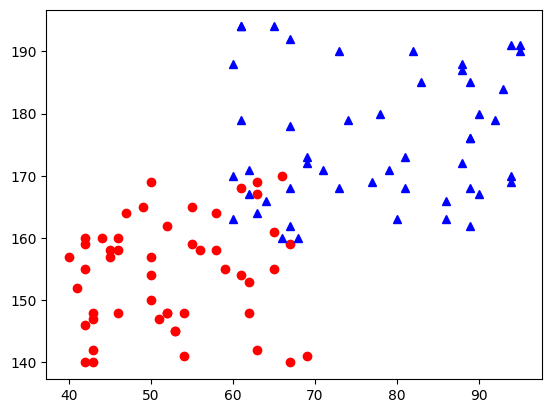

In [16]:
# print('여자 몸무게 :', [d[0] for d in data[::2]])
# print('여자 키 :', [d[1] for d in data[::2]])
# print('남자 몸무게 :', [d[0] for d in data[1::2]])
# print('남자 키 :', [d[1] for d in data[1::2]])
# for d in data[::2]:
#     plt.plot(d[0], d[1], 'o', c='r')
plt.plot([d[0] for d in data[::2]],[d[1] for d in data[::2]], 'o', c='r')
plt.plot([d[0] for d in data[1::2]],[d[1] for d in data[1::2]], '^', c='b')

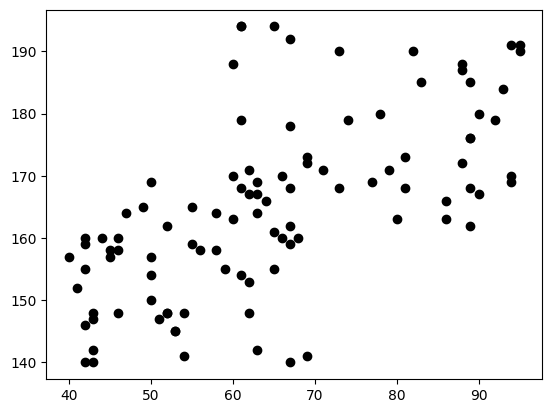

In [17]:
plt.plot([d[0] for d in data[::2]],[d[1] for d in data[::2]], 'o', c='k')
plt.plot([d[0] for d in data[1::2]],[d[1] for d in data[1::2]], 'o', c='k')

# 2. 군집화 로직

#### 초기 랜덤 지점 2개

In [18]:
# 초기 랜덤 지점 2개
random_points = [[random.randint(40, 95), random.randint(140, 195)], 
                 [random.randint(40, 95), random.randint(140, 195)]]
random_points

[[48, 179], [79, 165]]

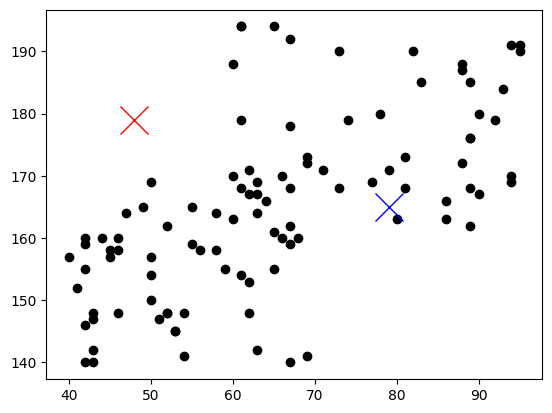

In [22]:
plt.plot([d[0] for d in data],[d[1] for d in data], 'o', c='k')
plt.plot(random_points[0][0],
         random_points[0][1], 'x', c='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
         random_points[1][1], 'x', c='b', markersize=20) # 기준점2

#### 두 점의 거리를 return

In [23]:
# 두 점의 거리를 return a:(0,0) ~ b:(4,3)
def dist(a, b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

In [24]:
a = [0, 0]; b=[4, 3]
dist(a, b)

5.0

#### 두 영역(random_points[0]과 random_points[1]을 기준으로 나눈 두 영역)

In [25]:
# 두 영역(random_points[0]과 random_points[1]을 기준으로 나눈 두 영역)
group1 = [] # random_points[0]이 가까운 그룹
group2 = [] # random_points[1]이 가까운 그룹
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group1.append(d) # 빨간 x랑 더 가까운 그룹
    else:
        group2.append(d) # 파란 x랑 더 가까운 그룹
len(group1), len(group2)

(40, 60)

#### 새로운 그룹 group1과 group2, 초기 랜덤 지점

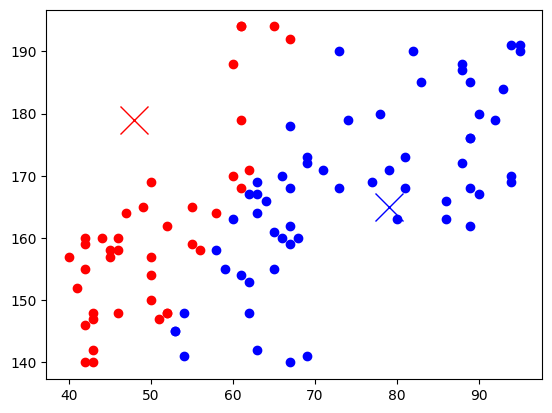

In [28]:
# 새로운 그룹 group1과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],[d[1] for d in group1], 'o', c='r')
plt.plot([d[0] for d in group2],[d[1] for d in group2], 'o', c='b')
plt.plot(random_points[0][0],
         random_points[0][1], 'x', c='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
         random_points[1][1], 'x', c='b', markersize=20) # 기준점2

#### 기준점 이동 group1의 중심점, group2의 중심점

In [29]:
# 기준점 이동 group1의 중심점, group2의 중심점
sumX=0 ; sumY=0
for g in group1:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[0] = [sumX/len(group1), sumY/len(group1)]

sumX=0 ; sumY=0
for g in group2:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[1] = [sumX/len(group2), sumY/len(group2)]
random_points

[[50.5, 161.175], [74.6, 167.58333333333334]]

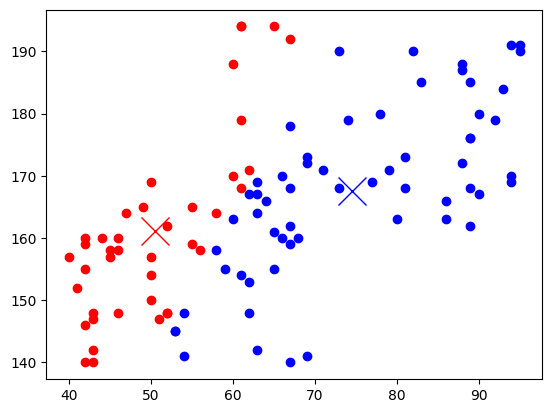

In [30]:
# 새로운 그룹 group1과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],[d[1] for d in group1], 'o', c='r')
plt.plot([d[0] for d in group2],[d[1] for d in group2], 'o', c='b')
plt.plot(random_points[0][0],
         random_points[0][1], 'x', c='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
         random_points[1][1], 'x', c='b', markersize=20) # 기준점2

# 3. 전체 코드(for문 이용)
- data 생성
- 랜덤포인트 2지점 임의로 생성
- for문
    - 랜덤포인트 2지점 기준으로 group1과 group2로 나눔
    - 랜덤포인터 이용(group1 중간점, group2 중간점)

초기 랜덤포인트 지점 :  [[43, 160], [71, 158]]
1 번째 랜덤포인트 지점 :  [[48.55555555555556, 155.66666666666666], [73.65753424657534, 169.91780821917808]]
2 번째 랜덤포인트 지점 :  [[53.425, 153.5], [75.85, 174.45]]
3 번째 랜덤포인트 지점 :  [[55.255319148936174, 154.4255319148936], [77.18867924528301, 176.39622641509433]]
4 번째 랜덤포인트 지점 :  [[55.816326530612244, 154.73469387755102], [77.50980392156863, 176.9607843137255]]
5 번째 랜덤포인트 지점 :  [[55.96, 155.02], [77.8, 177.12]]
6 번째 랜덤포인트 지점 :  [[55.96, 155.02], [77.8, 177.12]]
7 번째 랜덤포인트 지점 :  [[55.96, 155.02], [77.8, 177.12]]
8 번째 랜덤포인트 지점 :  [[55.96, 155.02], [77.8, 177.12]]
9 번째 랜덤포인트 지점 :  [[55.96, 155.02], [77.8, 177.12]]
10 번째 랜덤포인트 지점 :  [[55.96, 155.02], [77.8, 177.12]]


(140.0, 195.0)

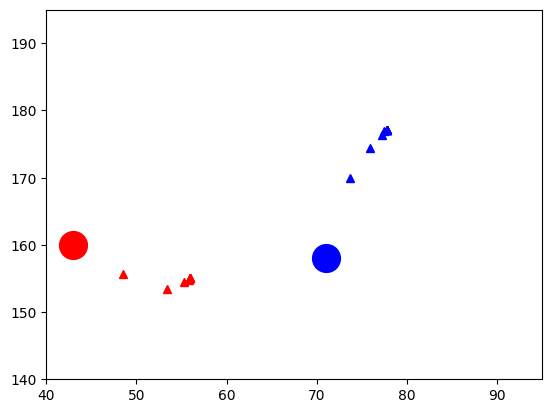

In [35]:
# 데이터 생성
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터
    data.append([random.randint(60, 95), random.randint(160, 195)])

# 랜덤 포인트 지정
points = [[random.randint(40, 95), random.randint(140,195)],
          [random.randint(40, 95), random.randint(140,195)]]
points

# for문
print('초기 랜덤포인트 지점 : ', points)
plt.plot(points[0][0], points[0][1], 'o', c='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'o', c='b', markersize=20)
for i in range(1, 11):
    group1 = [] # 랜덤포인트 points[0]과 가까운그룹
    group2 = [] # 랜덤포인트 points[1]과 가까운그룹
    for d in data:
        if dist(d, points[0]) < dist(d, points[1]):
            group1.append(d)
        else:
            group2.append(d)
    # 새로운 랜덤포인트로 할당
    sumX = 0; sumY = 0
    for g in group1:
        sumX += g[0]
        sumY += g[1]
    points[0] = [sumX/len(group1), sumY/len(group1)]
    sumX = 0; sumY = 0
    for g in group2:
        sumX += g[0]
        sumY += g[1]
    points[1] = [sumX/len(group2), sumY/len(group2)]
    print(i, '번째 랜덤포인트 지점 : ', points)
    plt.plot(points[0][0], points[0][1], '^', c='r')
    plt.plot(points[1][0], points[1][1], '^', c='b')
plt.xlim([40, 95])
plt.ylim([140, 195])

(50, 50)

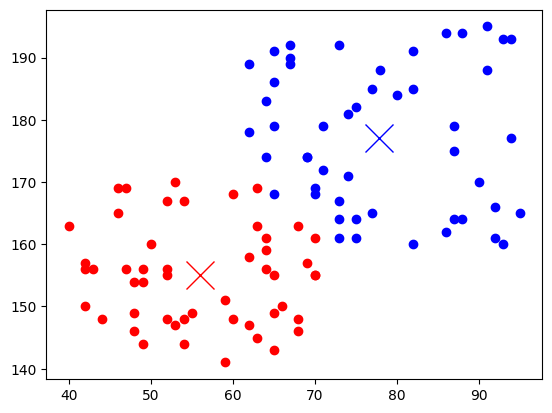

In [37]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', c='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', c='b')
plt.plot(points[0][0],
         points[0][1], 'x', c='r', markersize=20)
plt.plot(points[1][0],
         points[1][1], 'x', c='b', markersize=20)
len(group1), len(group2)

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝 패키지
    * 예측함수(예측모델) : 분류분석, 회귀분석, 군집분석
                          fit(학습), predict(예측)
    * 변환함수(변환모델) : 전처리함수 ex.스케일조정
                          fit(학습), transform(변환함수)

In [ ]:
# 군집분석 라이브러리가 joblib와 충돌 경고 메시지 출력
import os
os.environ["OMP_NUM_THREADS"] = "1"

#### 2번 군집화로직 길고긴 for문이 아래 KMeans로 끝남

In [44]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 2개 그룹으로 나눠
               init='random', # 초기 중심점을 랜덤하게해
               n_init=10, # 10번 실행해
               random_state=7, # 랜덤 지정
               )
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

#### --중심점

In [45]:
# 중심점
model.cluster_centers_

array([[ 78.06122449, 177.30612245],
       [ 56.1372549 , 155.2745098 ]])

#### --나눠진 그룹들의 인덱스

In [46]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [51]:
group1 = data[model.labels_ == 1]
group2 = data[model.labels_ == 0]
c1, c2 = model.cluster_centers_ # 중심점

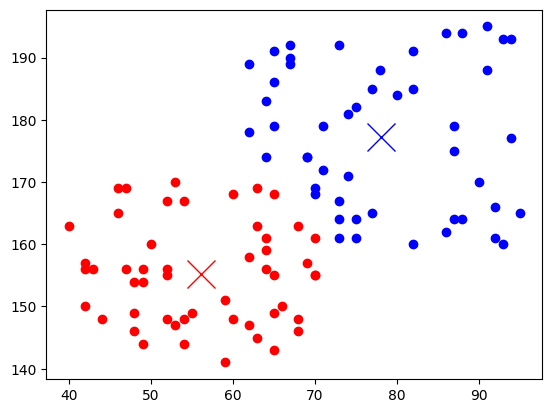

In [53]:
plt.plot([d[0] for d in group1], 
         [d[1] for d in group1], 'o', c='r')
plt.plot([d[0] for d in group2], 
         [d[1] for d in group2], 'o', c='b')
plt.plot(c2[0], c2[1], 'x', c='r', markersize=20) # group1의 중심점
plt.plot(c1[0], c1[1], 'x', c='b', markersize=20) # group2의 중심점